[[95.52010745]]


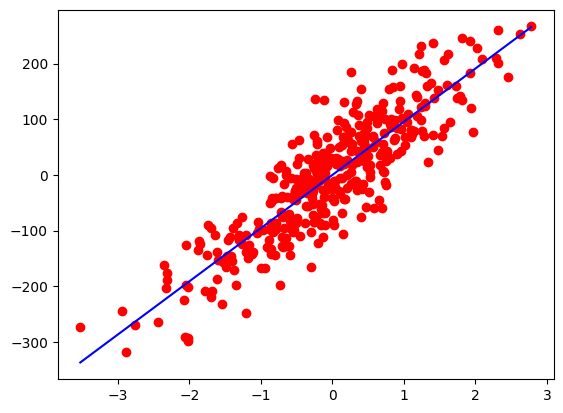

R2 0.7699743283650629


In [161]:
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error

x = pd.read_csv("https://github.com/koroteevmv/ML_course/raw/main/ML1.2%20multivariate/data/0_x.csv",
                header=None)
                # ,usecols=range(3))
y = pd.read_csv("https://github.com/koroteevmv/ML_course/raw/main/ML1.2%20multivariate/data/0_y.csv",
                header=None)

results = []

lin_bin = LinearRegression()
lin_bin.fit(x[[1]], y)
print(lin_bin.coef_)
y_pred = lin_bin.predict(x[[1]])

xx = np.linspace(x[[1]].min(), x[[1]].max(), 100)
plt.scatter(x[[1]], y, c='r')
plt.plot(xx, lin_bin.predict(xx), color='b')
plt.show()

R2 = lin_bin.score(x[[1]], y)
results.append({'Model': '1 признак', 'R2': R2, 'MAE': mean_absolute_error(y, y_pred), 'MSE': mean_squared_error(y, y_pred)})

print('R2', R2)


[[15.79537523 93.21521093 37.19410687 31.19129121 -0.23773114]]


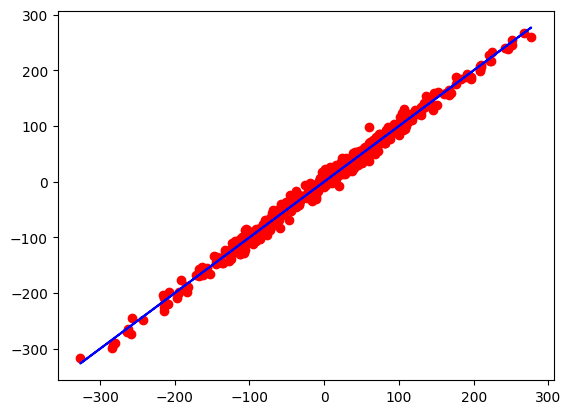

R2 0.9922198026415868


In [162]:
lin_mul = LinearRegression()
lin_mul.fit(x, y)
print(lin_mul.coef_)
y_pred = lin_mul.predict(x)

plt.scatter(y_pred, y, c='r')
plt.plot(y_pred, y_pred, color='b')
plt.show()

R2 = lin_mul.score(x, y)
results.append({'Model': '5 признаков' , 'R2': R2,  'MAE': mean_absolute_error(y, y_pred), 'MSE': mean_squared_error(y, y_pred)})

print('R2', R2)

[[22.78111342]]
R2 0.04364336234689348
[[95.52010745]]
R2 0.7699743283650629
[[46.94897635]]
R2 0.18794528514998887
[[23.99882407]]
R2 0.047470345664983093
[[1.49082042]]
R2 0.00017176151145947838


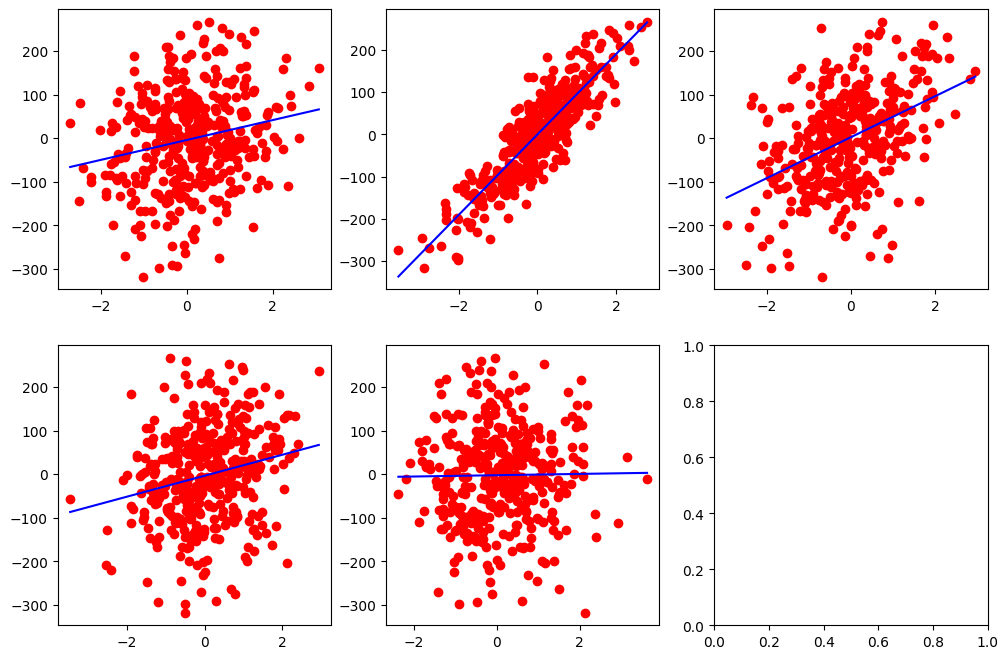

In [163]:
fig, ax = plt.subplots(2, 3, figsize=(12, 8))
ax = ax.ravel()

for x_attr in x:
    lin_bin = LinearRegression()
    lin_bin.fit(x[[x_attr]], y)
    print(lin_bin.coef_)
    y_pred = lin_bin.predict(x[[x_attr]])

    xx = np.linspace(x[[x_attr]].min(), x[[x_attr]].max(), 100)
    ax[x_attr].scatter(x[[x_attr]], y, c='r')
    ax[x_attr].plot(xx, lin_bin.predict(xx), color='b')

    R2 = lin_bin.score(x[[x_attr]], y)
    results.append({'Model': f'по {x_attr + 1} признаку' , 'R2': R2, 'MAE': mean_absolute_error(y, y_pred), 'MSE': mean_squared_error(y, y_pred)})
    print('R2', R2)
plt.show()




R2 0.9926004162659386
R2 0.9931922368118391
R2 1.0


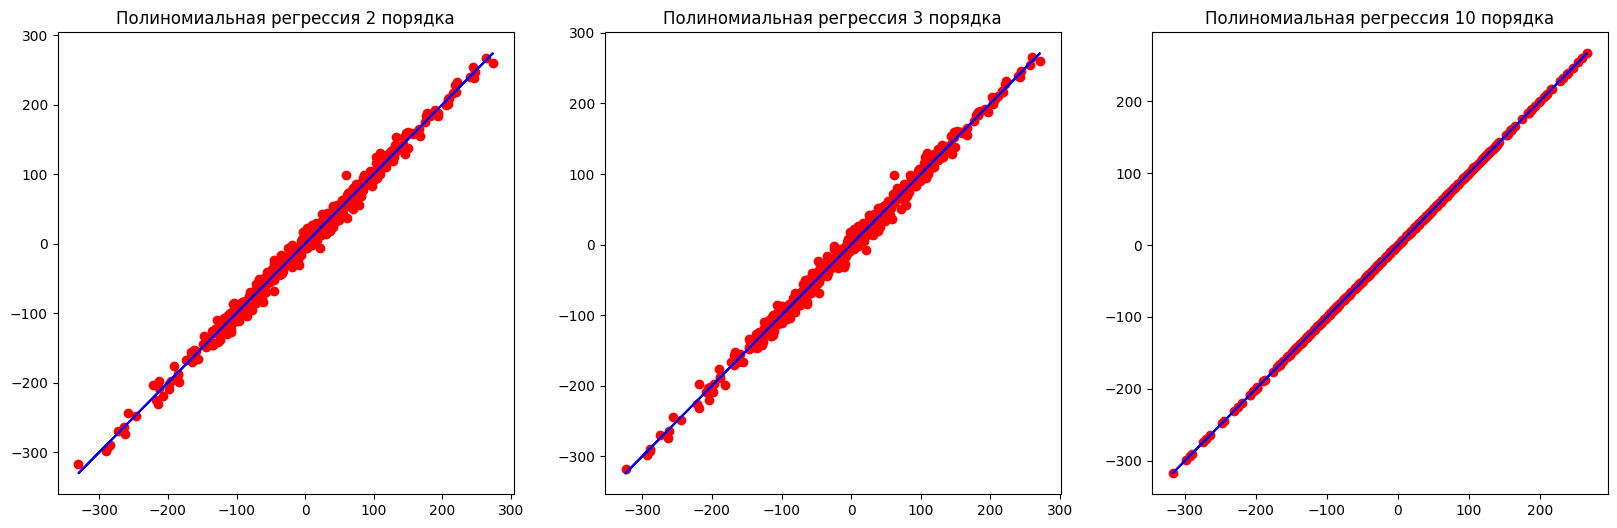

[0.0009663105010986328, 0.002885103225708008, 0.13251924514770508]


In [166]:
from sklearn.preprocessing import PolynomialFeatures
import time

fig, ax = plt.subplots(1, 3, figsize=(20, 6))
ax = ax.ravel()
c = 0
times = []

for p in [2, 3, 10]:
    poly = PolynomialFeatures(degree=p)
    x_poly = poly.fit_transform(x)

    lin_mul = LinearRegression()
    start = time.time()
    lin_mul.fit(x_poly, y)
    training_time = time.time() - start
    times.append(training_time)

    y_pred = lin_mul.predict(x_poly)

    ax[c].scatter(y_pred, y, c='r')
    ax[c].plot(y_pred, y_pred, color='b')
    ax[c].set_title(f'Полиномиальная регрессия {p} порядка')

    R2 = lin_mul.score(x_poly, y)
    results.append({'Model': f'полиномиальной регрессии {p} порядка', 'R2' : R2, 'MAE': mean_absolute_error(y, y_pred), 'MSE': mean_squared_error(y, y_pred)})
    print('R2',R2 )
    c += 1
plt.show()

print(times)

In [165]:
df = pd.json_normalize(results)

df



,Model,R2,MAE,MSE
0,1 признак,0.769974,4.213156e+01,2.764149e+03
1,5 признаков,0.992220,7.780684e+00,9.349229e+01
2,по 1 признаку,0.043643,8.576587e+01,1.149225e+04
3,по 2 признаку,0.769974,4.213156e+01,2.764149e+03
4,по 3 признаку,0.187945,7.741184e+01,9.758217e+03
5,по 4 признаку,0.047470,8.358678e+01,1.144626e+04
6,по 5 признаку,0.000172,8.719740e+01,1.201463e+04
7,полиномиальной регрессии 2 порядка,0.992600,7.553355e+00,8.891857e+01
8,полиномиальной регрессии 3 порядка,0.993192,7.095853e+00,8.180684e+01
9,полиномиальной регрессии 10 порядка,1.000000,1.380897e-10,1.503470e-19
